In [1]:
import os
import glob
import json
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. GLOBAL STYLING & DIRECTORY SETUP
# ==============================================================================
FIG_DIR = "figures"
EXTRACT_DIR = "/tmp/extracted_metrics"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "figure.titlesize": 13,
})

COLORS = {
    "vanilla": "#7f7f7f",     # Grey
    "double_dqn": "#1f77b4",  # Blue
    "dueling": "#e377c2",     # Pink / Magenta
    "multi_step": "#2ca02c",  # Green
}

DISPLAY_NAMES = {
    "vanilla": "Vanilla DQN",
    "double_dqn": "Double DQN",
    "dueling": "Dueling DQN",
    "multi_step": "N-Step DQN",
}

TAG_MAP = {
    "vanilla": "vanilla",
    "double": "double_dqn",
    "double_dqn": "double_dqn",
    "dueling": "dueling",
    "nstep": "multi_step",
    "multi_step": "multi_step",
}

def get_env_short_name(env_name: str) -> str:
    if "ALE/" in env_name:
        return env_name.split("/")[-1].split("-v")[0].lower()
    return env_name.lower()

def save_and_show(fig, filename: str, dpi: int = 300):
    filepath = os.path.join(FIG_DIR, filename)
    fig.savefig(filepath, dpi=dpi, bbox_inches="tight")
    print(f"✓ Figure saved to: {filepath}")
    plt.show()
    plt.close(fig)

# ==============================================================================
# 2. ROBUST DATA INGESTION & AUTO-UNZIP ENGINE
# ==============================================================================
def load_all_metrics(search_paths=("/kaggle/input", ".", "/tmp/extracted_metrics")) -> list[dict]:
    """
    Recursively scans mounted inputs, automatically unzips any uploaded archive datasets,
    normalizes experiment tags, and deduplicates preferring the longest runs.
    """
    print("--- Scanning Mounted Input Directories ---")
    if os.path.exists("/kaggle/input"):
        mounted_dirs = os.listdir("/kaggle/input")
        print(f"Mounted folders in /kaggle/input/: {mounted_dirs}")
    else:
        print("No /kaggle/input found (running locally).")

    # Step A: Automatically extract any .zip files in input folders
    for path in search_paths:
        if os.path.exists(path):
            for zip_path in glob.glob(os.path.join(path, "**", "*.zip"), recursive=True):
                try:
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(EXTRACT_DIR)
                        print(f"✓ Extracted zip archive: {os.path.basename(zip_path)}")
                except Exception as e:
                    print(f"Warning: Could not unzip {zip_path}: {e}")

    # Step B: Discover all metrics_*.json files
    json_files = []
    for path in search_paths:
        if os.path.exists(path):
            found = glob.glob(os.path.join(path, "**", "metrics_*.json"), recursive=True)
            json_files.extend(found)
            
    json_files = list(set(json_files))
    print(f"\nDiscovered {len(json_files)} metric JSON files across all sources.")

    unique_records = {}
    duplicates_filtered = 0

    for filepath in json_files:
        try:
            with open(filepath, "r") as f:
                data = json.load(f)

            env_name = data.get("env_name")
            raw_exp = data.get("experiment") or data.get("tag", "vanilla")
            canonical_exp = TAG_MAP.get(str(raw_exp).lower(), str(raw_exp).lower())
            seed = int(data.get("seed", 0))

            data["experiment"] = canonical_exp
            data["seed"] = seed

            key = (env_name, canonical_exp, seed)

            # If duplicate exists, keep the run with more frames/longer history (100k > 10k)
            if key in unique_records:
                existing_len = len(unique_records[key].get("scores", []))
                new_len = len(data.get("scores", []))
                if new_len > existing_len:
                    unique_records[key] = data
                duplicates_filtered += 1
            else:
                unique_records[key] = data

        except Exception as e:
            print(f"Warning: Failed to load {filepath}: {e}")

    results = list(unique_records.values())
    print(f"✓ Successfully assembled {len(results)} unique experiment runs (filtered {duplicates_filtered} duplicates).\n")

    envs_found = sorted(list(set(r["env_name"] for r in results)))
    exps_found = sorted(list(set(r["experiment"] for r in results)))
    print(f"  • Environments ({len(envs_found)}): {[get_env_short_name(e) for e in envs_found]}")
    print(f"  • Experiments ({len(exps_found)}): {[DISPLAY_NAMES.get(e, e) for e in exps_found]}\n")

    return results

# Run the updated loader
results = load_all_metrics()

--- Scanning Mounted Input Directories ---
Mounted folders in /kaggle/input/: ['notebooks', 'datasets']

Discovered 72 metric JSON files across all sources.
✓ Successfully assembled 48 unique experiment runs (filtered 24 duplicates).

  • Environments (4): ['demonattack', 'freeway', 'frostbite', 'krull']
  • Experiments (4): ['Double DQN', 'Dueling DQN', 'N-Step DQN', 'Vanilla DQN']



✓ Figure saved to: figures/Figure_1_Combined_Learning_Curves.png


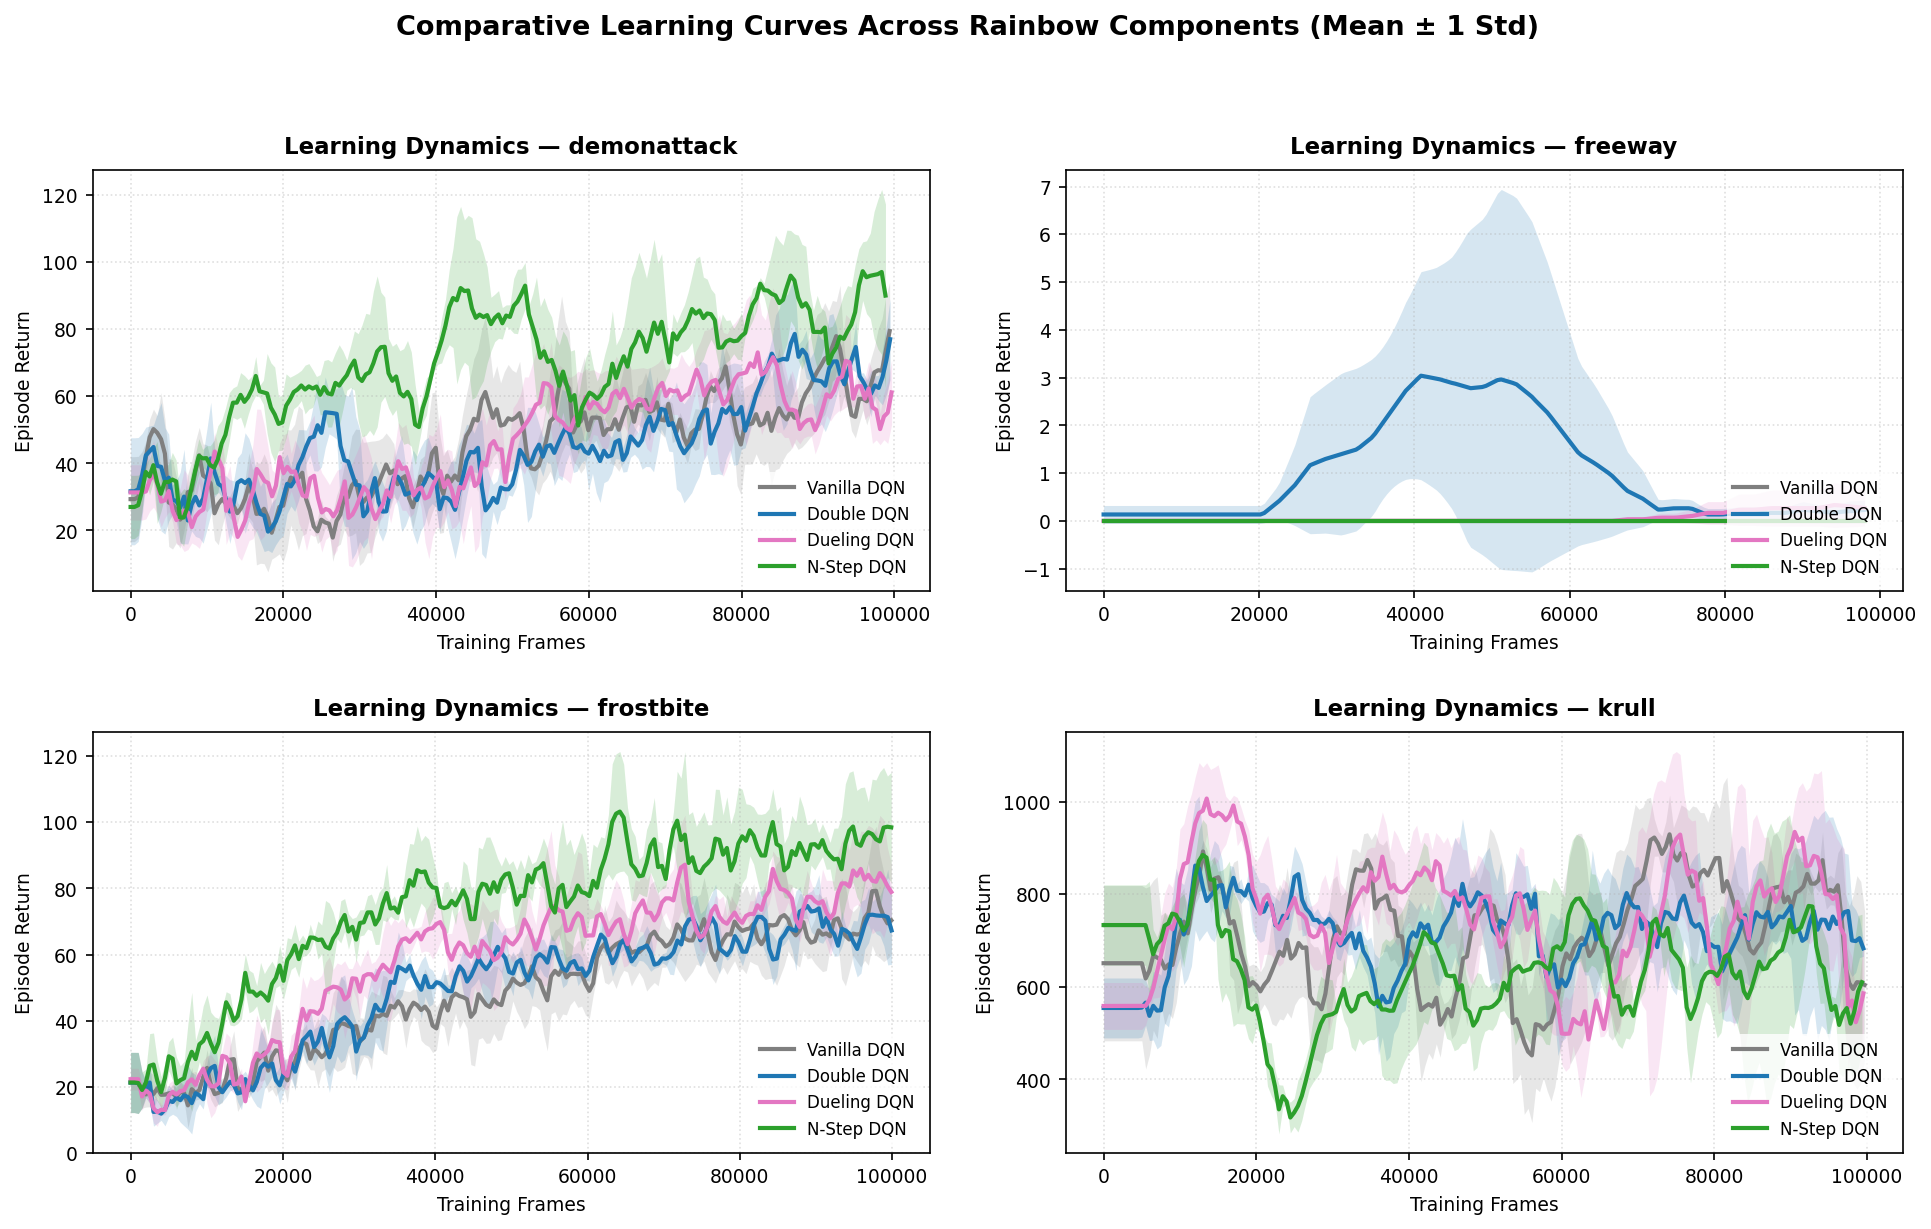

In [2]:
# ==============================================================================
# 3. FIGURE 1: 4-WAY COMPARATIVE LEARNING CURVES (2x2 GRID)
# ==============================================================================
def moving_average(data, window_size=10):
    """Smooths a sequence via simple moving average."""
    if len(data) < window_size:
        return np.array(data, dtype=np.float64)
    return np.convolve(data, np.ones(window_size) / window_size, mode="valid")

def aggregate_seeds_by_frame(results: list, env_name: str, exp_name: str, window_size=10, num_points=200):
    """
    Aligns runs across seeds onto a shared cumulative frame grid and
    computes the mean return with standard deviation bounds.
    """
    seed_series = []
    max_common_frame = None
    
    for r in results:
        if r["env_name"] != env_name or r["experiment"] != exp_name:
            continue
        scores = r.get("scores", [])
        lengths = r.get("episode_lengths", [])
        if not scores or not lengths:
            continue
            
        smoothed = moving_average(scores, window_size=window_size)
        cum_frames = np.cumsum(lengths)
        offset = len(scores) - len(smoothed)
        frame_x = cum_frames[offset:]
        
        if len(frame_x) == 0:
            continue
            
        seed_series.append((frame_x, smoothed))
        max_common_frame = frame_x[-1] if max_common_frame is None else min(max_common_frame, frame_x[-1])
        
    if not seed_series or max_common_frame is None or max_common_frame == 0:
        return None
        
    grid = np.linspace(0, max_common_frame, num_points)
    interpolated = np.stack([np.interp(grid, fx, s) for fx, s in seed_series])
    
    center = interpolated.mean(axis=0)
    spread = interpolated.std(axis=0)
    return grid, center, center - spread, center + spread

def plot_figure_1_combined_learning_curves(results):
    environments = sorted(list(set(r["env_name"] for r in results)))
    experiments = ["vanilla", "double_dqn", "dueling", "multi_step"]
    
    n_envs = len(environments)
    ncols = min(2, max(1, n_envs))
    nrows = int(np.ceil(n_envs / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.2 * nrows), dpi=150, squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, env_name in enumerate(environments):
        ax = axes_flat[idx]
        short_name = get_env_short_name(env_name)
        
        for exp_name in experiments:
            agg = aggregate_seeds_by_frame(results, env_name, exp_name, window_size=10)
            if agg is None:
                continue
                
            frames, mean_val, lower, upper = agg
            color = COLORS.get(exp_name, "#333333")
            label = DISPLAY_NAMES.get(exp_name, exp_name)
            
            ax.plot(frames, mean_val, linewidth=2.0, color=color, label=label)
            ax.fill_between(frames, lower, upper, color=color, alpha=0.18, linewidth=0)
            
        ax.set_title(f"Learning Dynamics — {short_name}", fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Training Frames", fontsize=9)
        ax.set_ylabel("Episode Return", fontsize=9)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
    for idx in range(n_envs, len(axes_flat)):
        axes_flat[idx].axis("off")
        
    fig.suptitle("Comparative Learning Curves Across Rainbow Components (Mean ± 1 Std)", 
                 fontsize=13, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95], h_pad=2.2, w_pad=2.0)
    save_and_show(fig, "Figure_1_Combined_Learning_Curves.png")

plot_figure_1_combined_learning_curves(results)

✓ Figure saved to: figures/Figure_2_Relative_Improvement_Over_Vanilla.png


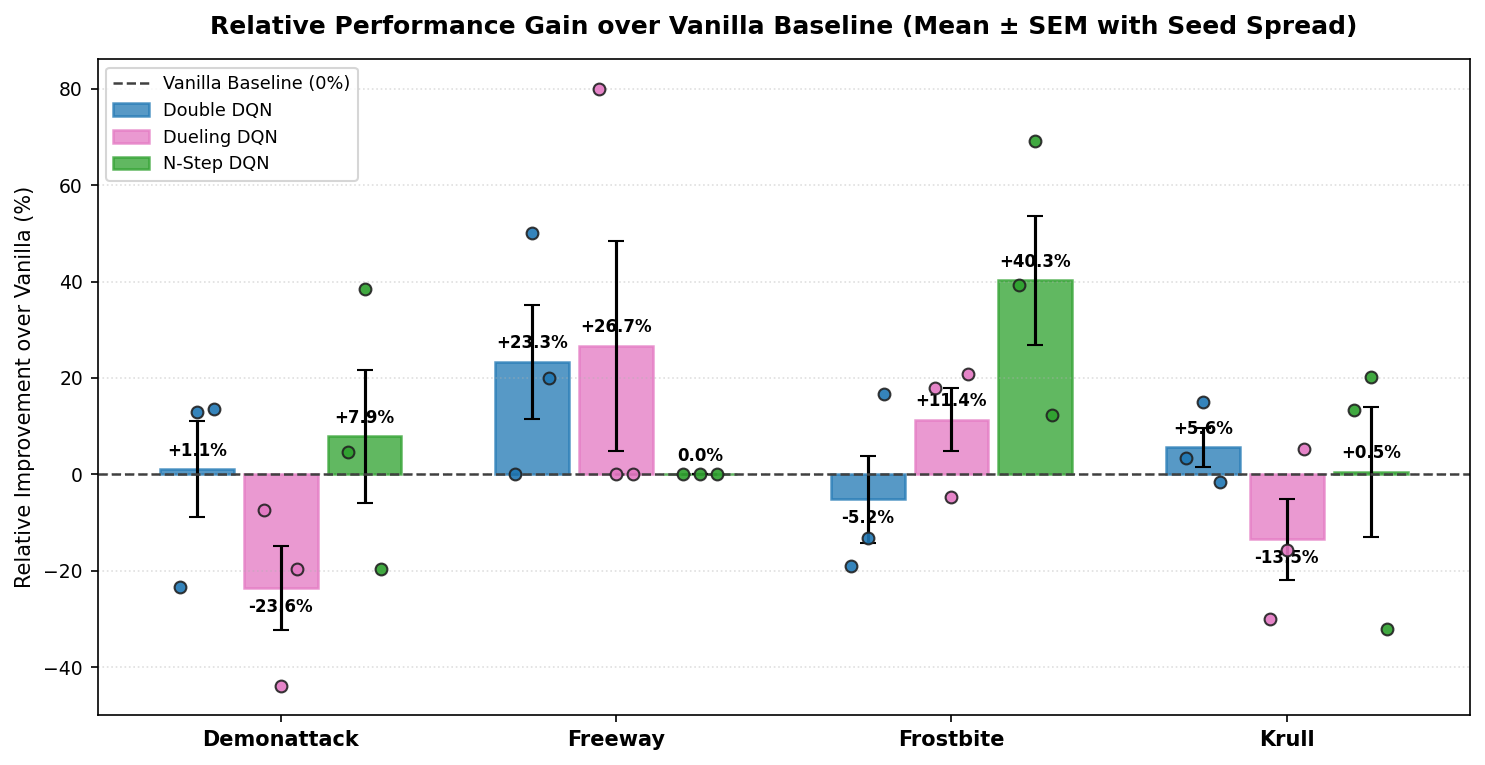

In [3]:
# ==============================================================================
# 4. FIGURE 2: RELATIVE NORMALIZED GAIN OVER VANILLA BASELINE (WITH SEED JITTER)
# ==============================================================================
def plot_figure_2_relative_improvement(results):
    environments = sorted(list(set(r["env_name"] for r in results)))
    # Ablations compared against Vanilla
    ablations = [e for e in ["double_dqn", "dueling", "multi_step"] 
                 if any(r["experiment"] == e for r in results)]
    
    if not ablations:
        print("Skipping Figure 2: No ablation data found to compare against Vanilla.")
        return

    n_envs = len(environments)
    n_ablations = len(ablations)
    
    x = np.arange(n_envs)
    total_group_width = 0.75
    bar_width = total_group_width / max(1, n_ablations)
    
    fig, ax = plt.subplots(figsize=(10, 5.2), dpi=150)
    
    for i, exp_name in enumerate(ablations):
        mean_gains = []
        sem_gains = []
        all_seed_gains = []
        bar_x_positions = []
        
        for env_idx, env_name in enumerate(environments):
            # Compute Vanilla Baseline (mean of final 10 episodes across all vanilla seeds)
            v_matches = [r for r in results if r["env_name"] == env_name and r["experiment"] == "vanilla"]
            v_finals = [np.mean(r["scores"][-10:]) for r in v_matches if r.get("scores")]
            v_baseline = float(np.mean(v_finals)) if v_finals else 0.0
            
            # Robust denominator (prevents division by zero for sparse games like Freeway)
            denom = max(abs(v_baseline), 1.0)
            
            # Compute percentage gain for each seed of this ablation
            exp_matches = [r for r in results if r["env_name"] == env_name and r["experiment"] == exp_name]
            seed_finals = [np.mean(r["scores"][-10:]) for r in exp_matches if r.get("scores")]
            
            seed_pct_gains = [((score - v_baseline) / denom) * 100.0 for score in seed_finals]
            
            if seed_pct_gains:
                avg_gain = float(np.mean(seed_pct_gains))
                sem_gain = float(np.std(seed_pct_gains) / np.sqrt(len(seed_pct_gains))) if len(seed_pct_gains) > 1 else 0.0
            else:
                avg_gain = 0.0
                sem_gain = 0.0
                
            mean_gains.append(avg_gain)
            sem_gains.append(sem_gain)
            all_seed_gains.append(seed_pct_gains)
            bar_x_positions.append(x[env_idx] - (total_group_width / 2) + (i + 0.5) * bar_width)
            
        color = COLORS.get(exp_name, "#333333")
        label = DISPLAY_NAMES.get(exp_name, exp_name)
        
        # Plot Mean Bars
        bars = ax.bar(bar_x_positions, mean_gains, width=bar_width * 0.88, yerr=sem_gains, 
                      capsize=4, color=color, alpha=0.75, edgecolor=color, linewidth=1.2, label=label)
        
        # Overlay Individual Seed Points with Jitter
        for b_idx, seed_pts in enumerate(all_seed_gains):
            center_x = bar_x_positions[b_idx]
            jitter = np.linspace(-bar_width * 0.2, bar_width * 0.2, len(seed_pts)) if len(seed_pts) > 1 else [0]
            ax.scatter(center_x + jitter, seed_pts, color=color, edgecolor="#222222", 
                       s=32, zorder=4, alpha=0.9)
            
        # Add Percentage Text Labels
        for b_pos, gain in zip(bar_x_positions, mean_gains):
            sign = "+" if gain > 0 else ""
            va = "bottom" if gain >= 0 else "top"
            offset = 2.0 if gain >= 0 else -2.0
            ax.text(b_pos, gain + offset, f"{sign}{gain:.1f}%", ha="center", va=va, fontsize=8, fontweight="bold")
            
    # Reference Line at 0% (Vanilla Baseline)
    ax.axhline(0.0, color="#404040", linestyle="--", linewidth=1.2, zorder=2, label="Vanilla Baseline (0%)")
    
    ax.set_xticks(x)
    ax.set_xticklabels([get_env_short_name(e).capitalize() for e in environments], fontsize=10, fontweight="bold")
    ax.set_ylabel("Relative Improvement over Vanilla (%)", fontsize=10)
    ax.set_title("Relative Performance Gain over Vanilla Baseline (Mean ± SEM with Seed Spread)", 
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=8.5)
    
    fig.tight_layout()
    save_and_show(fig, "Figure_2_Relative_Improvement_Over_Vanilla.png")

plot_figure_2_relative_improvement(results)

✓ Figure saved to: figures/Figure_3_Action_Diversity_Entropy.png


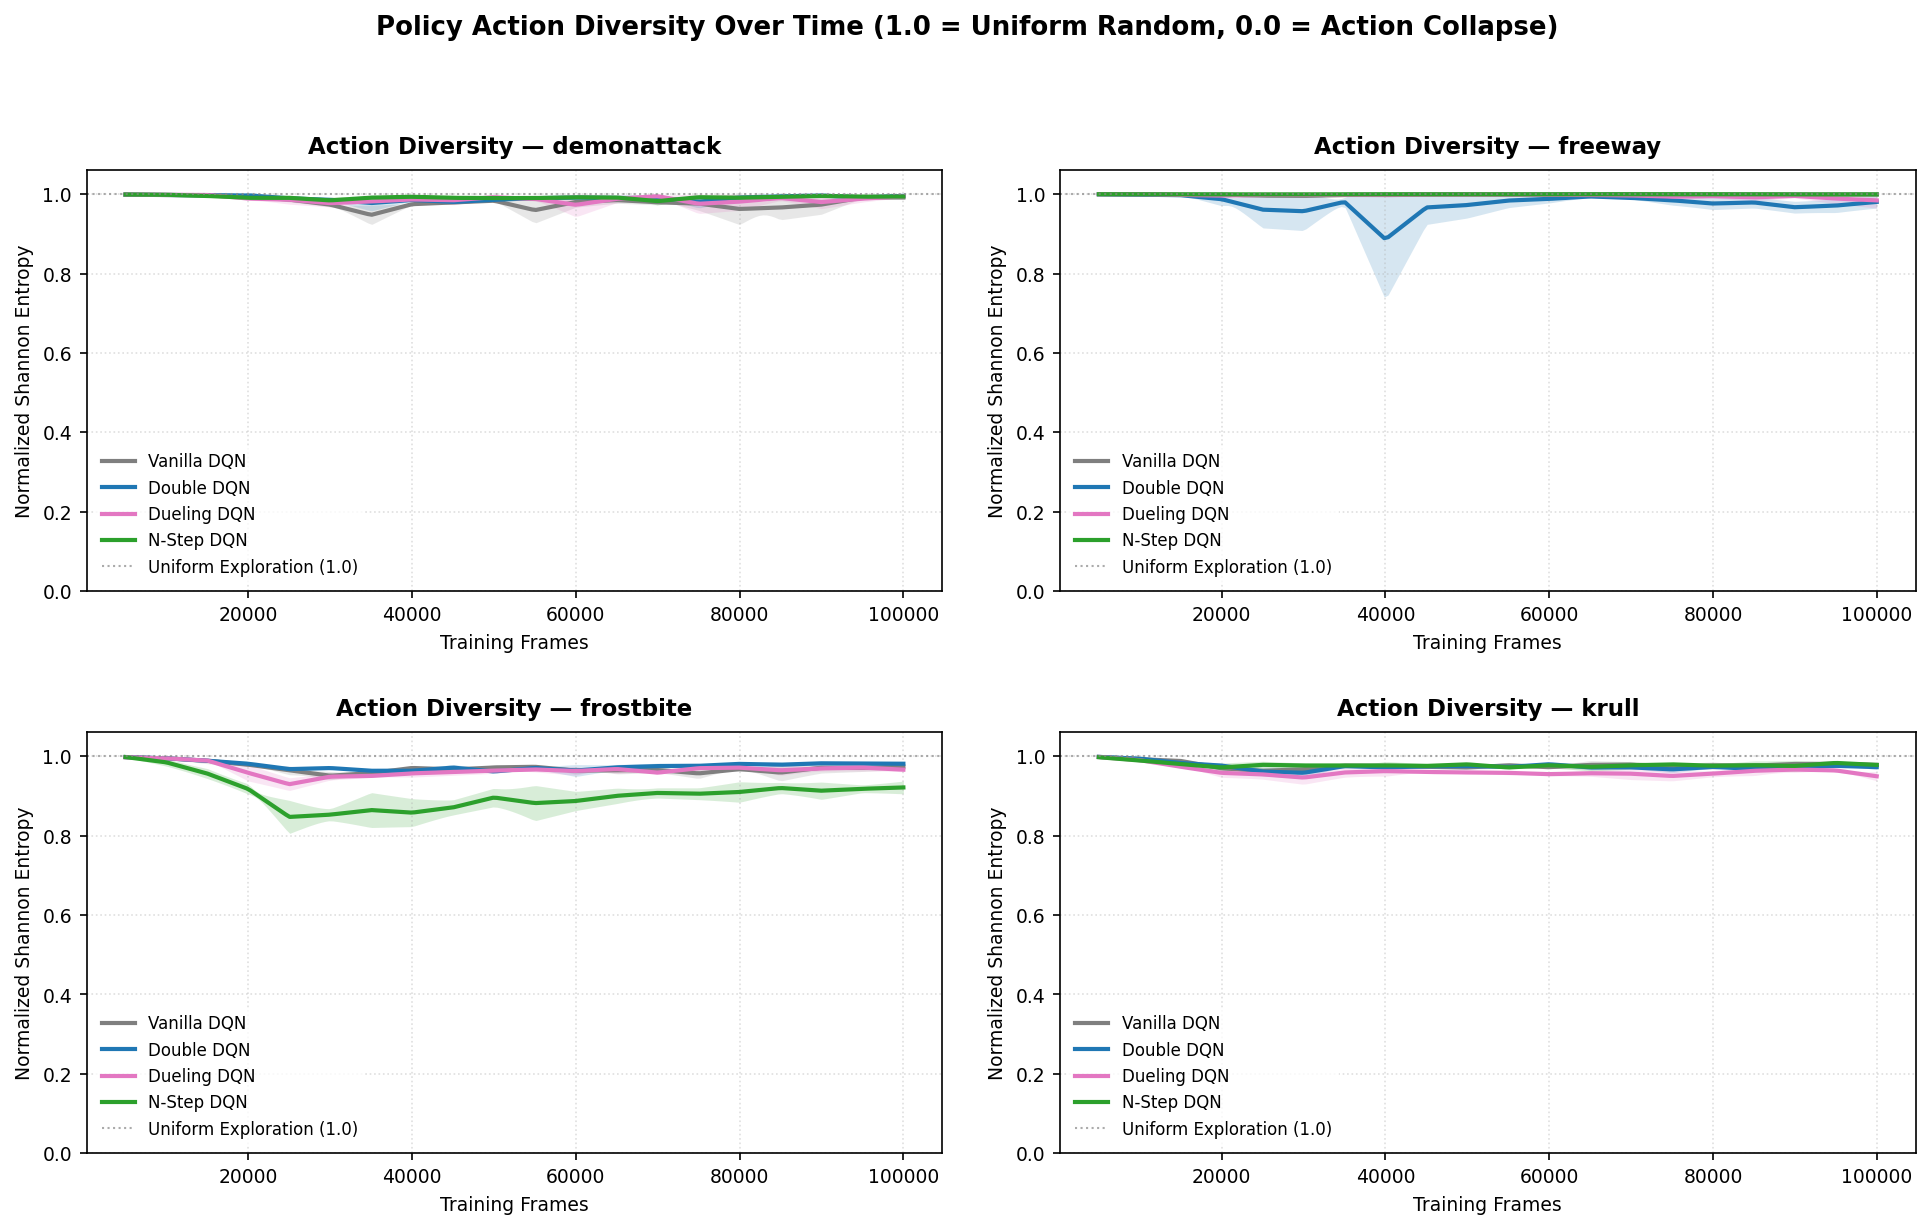

In [4]:
# ==============================================================================
# 5. FIGURE 3: COMPARATIVE ACTION DIVERSITY & SHANNON ENTROPY (2x2 GRID)
# ==============================================================================
def compute_normalized_entropy(pct_vector):
    """Computes normalized Shannon entropy H / ln(|A|) from a probability vector."""
    p = np.array(pct_vector, dtype=np.float64)
    # Remove zeros to avoid log(0)
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    action_dim = len(pct_vector)
    if action_dim <= 1:
        return 1.0
    entropy = -np.sum(p * np.log(p))
    return float(entropy / np.log(action_dim))

def aggregate_entropy_by_frame(results: list, env_name: str, exp_name: str, num_points=200):
    """
    Extracts action history for all seeds, converts to normalized entropy series,
    and linearly interpolates onto a shared frame grid.
    """
    seed_series = []
    max_common_frame = None
    
    for r in results:
        if r["env_name"] != env_name or r["experiment"] != exp_name:
            continue
        history = r.get("action_history", [])
        if not history:
            continue
            
        frames = [entry[0] for entry in history]
        entropies = [compute_normalized_entropy(entry[1]) for entry in history]
        
        if len(frames) == 0:
            continue
            
        seed_series.append((np.array(frames), np.array(entropies)))
        max_common_frame = frames[-1] if max_common_frame is None else min(max_common_frame, frames[-1])
        
    if not seed_series or max_common_frame is None or max_common_frame == 0:
        return None
        
    grid = np.linspace(seed_series[0][0][0], max_common_frame, num_points)
    interpolated = np.stack([np.interp(grid, fx, ent) for fx, ent in seed_series])
    
    center = interpolated.mean(axis=0)
    spread = interpolated.std(axis=0)
    return grid, center, np.clip(center - spread, 0.0, 1.0), np.clip(center + spread, 0.0, 1.0)


# --- RENDER FIGURE 3: COMPARATIVE ACTION ENTROPY ---
def plot_figure_3_action_diversity(results):
    environments = sorted(list(set(r["env_name"] for r in results)))
    experiments = ["vanilla", "double_dqn", "dueling", "multi_step"]
    
    n_envs = len(environments)
    ncols = min(2, max(1, n_envs))
    nrows = int(np.ceil(n_envs / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.2 * nrows), dpi=150, squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, env_name in enumerate(environments):
        ax = axes_flat[idx]
        short_name = get_env_short_name(env_name)
        
        for exp_name in experiments:
            agg = aggregate_entropy_by_frame(results, env_name, exp_name)
            if agg is None:
                continue
                
            frames, mean_ent, lower, upper = agg
            color = COLORS.get(exp_name, "#333333")
            label = DISPLAY_NAMES.get(exp_name, exp_name)
            
            ax.plot(frames, mean_ent, linewidth=2.0, color=color, label=label)
            ax.fill_between(frames, lower, upper, color=color, alpha=0.18, linewidth=0)
            
        # Reference Line for Uniform Random Exploration (1.0)
        ax.axhline(1.0, color="#888888", linestyle=":", linewidth=1.0, alpha=0.7, label="Uniform Exploration (1.0)")
        
        ax.set_title(f"Action Diversity — {short_name}", fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Training Frames", fontsize=9)
        ax.set_ylabel("Normalized Shannon Entropy", fontsize=9)
        ax.set_ylim(0.0, 1.06)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
        
    for idx in range(n_envs, len(axes_flat)):
        axes_flat[idx].axis("off")
        
    fig.suptitle("Policy Action Diversity Over Time (1.0 = Uniform Random, 0.0 = Action Collapse)", 
                 fontsize=12.5, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95], h_pad=2.2, w_pad=2.0)
    save_and_show(fig, "Figure_3_Action_Diversity_Entropy.png")

plot_figure_3_action_diversity(results)

✓ Figure saved to: figures/Figure_5_Sample_Efficiency_AUC.png


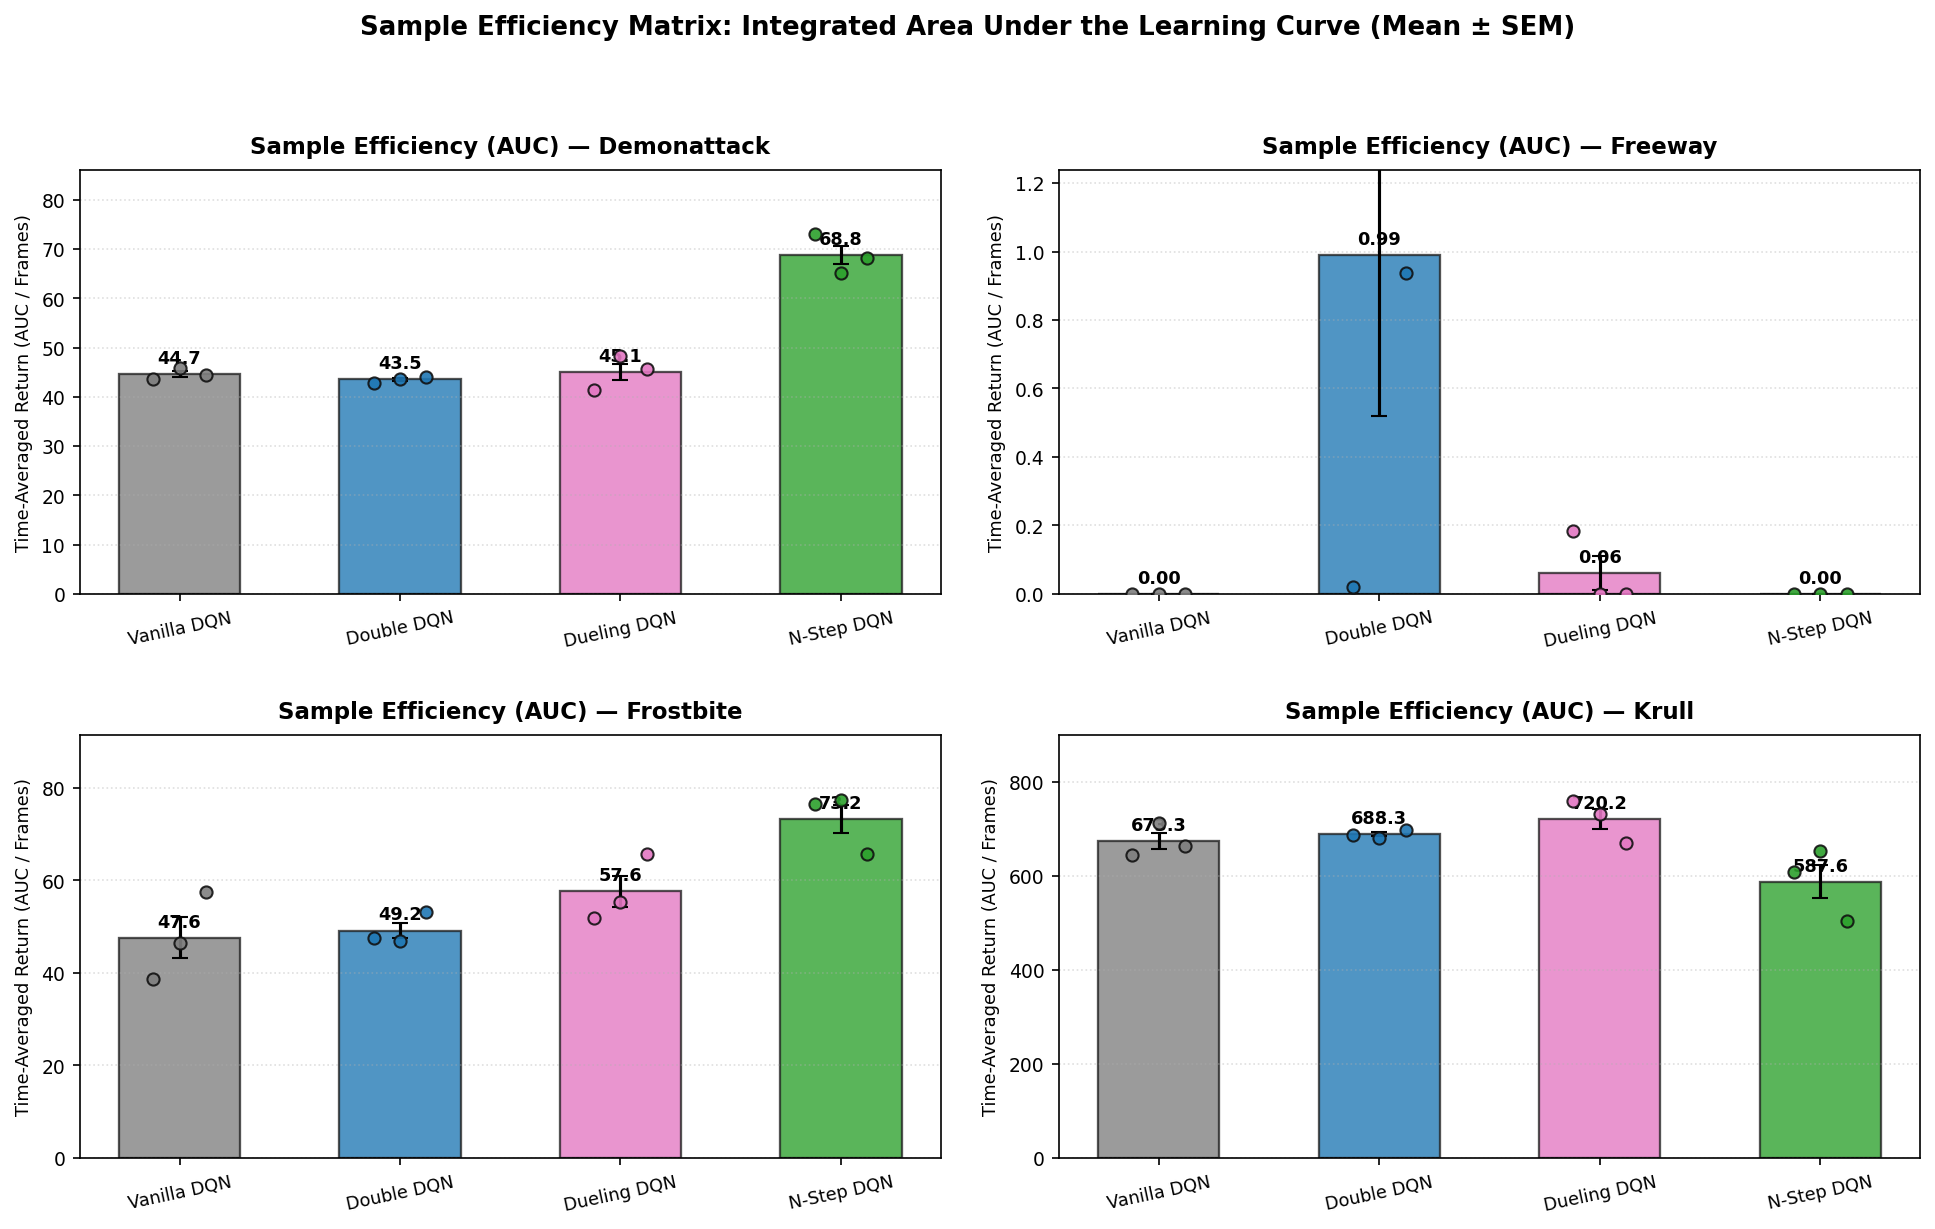

In [5]:
# ==============================================================================
# 6. FIGURE 5: SAMPLE EFFICIENCY & TIME-AVERAGED AUC (2x2 GRID)
# ==============================================================================
# Cross-version safe numerical trapezoidal integration (NumPy 1.x & 2.x compatible)
trapezoid_fn = getattr(np, "trapezoid", getattr(np, "trapz", None))

def compute_run_auc(run_dict, window_size=10):
    """
    Computes the normalized time-averaged return (AUC / T_max)
    for a single seed run across its cumulative frame trajectory.
    """
    scores = run_dict.get("scores", [])
    lengths = run_dict.get("episode_lengths", [])
    if not scores or not lengths:
        return 0.0
        
    smoothed = moving_average(scores, window_size=window_size)
    cum_frames = np.cumsum(lengths)
    offset = len(scores) - len(smoothed)
    frame_x = cum_frames[offset:]
    
    if len(frame_x) < 2 or frame_x[-1] == 0:
        return float(np.mean(scores))
        
    # Normalized integral: average score experienced per frame over training
    total_area = trapezoid_fn(smoothed, frame_x)
    return float(total_area / frame_x[-1])

def plot_figure_5_sample_efficiency_auc(results):
    environments = sorted(list(set(r["env_name"] for r in results)))
    experiments = ["vanilla", "double_dqn", "dueling", "multi_step"]
    # Filter for experiments actually present in data
    active_exps = [e for e in experiments if any(r["experiment"] == e for r in results)]
    
    n_envs = len(environments)
    ncols = min(2, max(1, n_envs))
    nrows = int(np.ceil(n_envs / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.2 * nrows), dpi=150, squeeze=False)
    axes_flat = axes.flatten()
    
    for idx, env_name in enumerate(environments):
        ax = axes_flat[idx]
        short_name = get_env_short_name(env_name)
        
        exp_labels = []
        mean_aucs = []
        sem_aucs = []
        all_seed_aucs = []
        bar_colors = []
        
        for exp_name in active_exps:
            matches = [r for r in results if r["env_name"] == env_name and r["experiment"] == exp_name]
            seed_aucs = [compute_run_auc(r) for r in matches if r.get("scores")]
            
            if not seed_aucs:
                continue
                
            mean_val = float(np.mean(seed_aucs))
            sem_val = float(np.std(seed_aucs) / np.sqrt(len(seed_aucs))) if len(seed_aucs) > 1 else 0.0
            
            exp_labels.append(DISPLAY_NAMES.get(exp_name, exp_name))
            mean_aucs.append(mean_val)
            sem_aucs.append(sem_val)
            all_seed_aucs.append(seed_aucs)
            bar_colors.append(COLORS.get(exp_name, "#333333"))
            
        x_pos = np.arange(len(exp_labels))
        
        # Plot Mean AUC Bars
        bars = ax.bar(x_pos, mean_aucs, yerr=sem_aucs, capsize=4, width=0.55,
                      color=bar_colors, alpha=0.78, edgecolor="#222222", linewidth=1.1)
        
        # Overlay Individual Seed Points with Jitter
        for b_idx, seed_pts in enumerate(all_seed_aucs):
            jitter = np.linspace(-0.12, 0.12, len(seed_pts)) if len(seed_pts) > 1 else [0]
            ax.scatter(x_pos[b_idx] + jitter, seed_pts, color=bar_colors[b_idx], 
                       edgecolor="#111111", s=34, zorder=4, alpha=0.9)
            
        # Value text annotations above bars
        for bar, val in zip(bars, mean_aucs):
            fmt_str = f"{val:.2f}" if abs(val) < 10 else f"{val:.1f}"
            y_offset = (max(mean_aucs) * 0.02) if max(mean_aucs) > 0 else 0.05
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_offset, 
                    fmt_str, ha="center", va="bottom", fontsize=8.5, fontweight="bold")
            
        ax.set_title(f"Sample Efficiency (AUC) — {short_name.capitalize()}", fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(exp_labels, fontsize=8.5, rotation=12)
        ax.set_ylabel("Time-Averaged Return (AUC / Frames)", fontsize=8.5)
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)
        
        # Expand Y-lim slightly to leave room for text labels
        if mean_aucs and max(mean_aucs) > 0:
            ax.set_ylim(0, max(mean_aucs) * 1.25)
            
    for idx in range(n_envs, len(axes_flat)):
        axes_flat[idx].axis("off")
        
    fig.suptitle("Sample Efficiency Matrix: Integrated Area Under the Learning Curve (Mean ± SEM)", 
                 fontsize=12.5, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95], h_pad=2.4, w_pad=2.0)
    save_and_show(fig, "Figure_5_Sample_Efficiency_AUC.png")

plot_figure_5_sample_efficiency_auc(results)